# AegisHealth ML Pipeline — Complete Demo

This notebook walks through **every ML component** of AegisHealth end-to-end:

| # | Section | What it demonstrates |
|---|---------|---------------------|
| 1 | **Setup** | Imports, device detection, path configuration |
| 2 | **Synthetic Data** | Generate realistic multi-client vital-signs data (no eICU download required) |
| 3 | **Preprocessing** | Sliding-window extraction, z-score normalisation, label generation |
| 4 | **LSTM Model** | Architecture inspection, parameter count, forward pass |
| 5 | **Centralized Training** | Single-model baseline with class-weighted loss |
| 6 | **Federated Learning** | Multi-client FedProx simulation with the Orchestrator |
| 7 | **Differential Privacy** | Opacus DP-SGD integration and privacy accounting |
| 8 | **Homomorphic Encryption** | TenSEAL CKKS secure aggregation |
| 9 | **Threshold Optimisation** | F-beta search for clinical decision boundary |
| 10 | **ONNX Export** | Production model export with dynamic batching |
| 11 | **Visualisation** | Training curves, ROC, confusion matrix, privacy budget |

---
## 1. Setup & Imports

In [1]:
import sys, os
from pathlib import Path

BACKEND_ROOT = Path(os.getcwd()).parent  # backend/
if str(BACKEND_ROOT) not in sys.path:
    sys.path.insert(0, str(BACKEND_ROOT))

import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib
from sklearn.metrics import (
    roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
)

matplotlib.rcParams.update({
    "figure.facecolor": "#0e1117",
    "axes.facecolor": "#0e1117",
    "axes.edgecolor": "#3a3f4b",
    "axes.labelcolor": "#c9d1d9",
    "text.color": "#c9d1d9",
    "xtick.color": "#8b949e",
    "ytick.color": "#8b949e",
    "grid.color": "#21262d",
    "legend.facecolor": "#161b22",
    "legend.edgecolor": "#30363d",
    "figure.dpi": 120,
    "font.size": 10,
})

ACCENT = "#58a6ff"
ACCENT2 = "#f78166"
ACCENT3 = "#3fb950"
ACCENT4 = "#d2a8ff"

from app.ml.lstm_model import LSTMAnomalyDetector, create_model
from app.ml.trainer import train_local, evaluate, collect_probs, find_optimal_threshold, get_device, TrainResult
from app.ml.dp_engine import DPEngine, PrivacyAccountant
from app.ml.he_engine import (
    create_he_context, create_public_context,
    encrypt_state_dict, decrypt_state_dict,
    encrypted_weighted_average, secure_aggregate, ciphertext_size_bytes,
)
from app.data.loader import create_data_loaders
from app.core.aggregator import federated_average, FedProxAggregator
from app.data.preprocessor import VITAL_FEATURES

device = get_device()
print(f"Backend root : {BACKEND_ROOT}")
print(f"PyTorch      : {torch.__version__}")
print(f"Device       : {device}")
print(f"Vital features ({len(VITAL_FEATURES)}): {VITAL_FEATURES}")

Backend root : /Users/chamika/Desktop/aegishealth/backend
PyTorch      : 2.11.0
Device       : mps
Vital features (11): ['heartrate', 'respiration', 'sao2', 'temperature', 'systemicsystolic', 'systemicdiastolic', 'systemicmean', 'cvp', 'st1', 'st2', 'st3']


---
## 2. Synthetic Data Generation

We create **synthetic ICU vital-sign data** that mirrors the real eICU schema so the entire pipeline runs without downloading the dataset.  Each synthetic "hospital" (client) gets realistic vital distributions with injected critical-event windows.

In [2]:
import tempfile, shutil

N_CLIENTS = 4
PATIENTS_PER_CLIENT = 40
VITALS_PER_PATIENT = 120
EVENT_RATE = 0.25
SEQ_LEN = 24
PRED_HORIZON = 360

rng = np.random.default_rng(42)

VITAL_RANGES = {
    "heartrate":        (60, 100),
    "respiration":      (12, 20),
    "sao2":             (92, 100),
    "temperature":      (36.0, 37.5),
    "systemicsystolic": (100, 140),
    "systemicdiastolic":(60, 90),
    "systemicmean":     (70, 105),
    "cvp":              (2, 12),
    "st1":              (-0.5, 0.5),
    "st2":              (-0.5, 0.5),
    "st3":              (-0.5, 0.5),
}

SYNTH_DIR = Path(tempfile.mkdtemp(prefix="aegis_synth_"))

for cid in range(N_CLIENTS):
    client_dir = SYNTH_DIR / f"client_{cid}"
    client_dir.mkdir()

    pids = list(range(cid * 1000, cid * 1000 + PATIENTS_PER_CLIENT))
    patients_df = pd.DataFrame({"patientunitstayid": pids})

    vitals_rows = []
    events_rows = []

    for pid in pids:
        has_event = rng.random() < EVENT_RATE
        total_minutes = VITALS_PER_PATIENT * 5

        if has_event:
            event_offset = rng.integers(PRED_HORIZON, total_minutes)
            events_rows.append({"patientunitstayid": pid, "event_offset": event_offset})
        else:
            event_offset = None

        for t in range(VITALS_PER_PATIENT):
            offset = t * 5
            row = {"patientunitstayid": pid, "observationoffset": offset}

            approaching_event = (
                event_offset is not None
                and (event_offset - PRED_HORIZON) <= offset < event_offset
            )

            for feat, (lo, hi) in VITAL_RANGES.items():
                base = rng.uniform(lo, hi)
                noise = rng.normal(0, (hi - lo) * 0.05)
                if approaching_event:
                    if feat == "heartrate":
                        base += 30
                    elif feat == "systemicsystolic":
                        base -= 25
                    elif feat == "sao2":
                        base -= 6
                row[feat] = round(base + noise, 2)
            vitals_rows.append(row)

    patients_df.to_csv(client_dir / "patients.csv", index=False)
    pd.DataFrame(vitals_rows).to_csv(client_dir / "vitals.csv", index=False)
    pd.DataFrame(events_rows).to_csv(client_dir / "events.csv", index=False)

print(f"Synthetic data created at: {SYNTH_DIR}")
for d in sorted(SYNTH_DIR.iterdir()):
    files = list(d.iterdir())
    sizes = {f.name: f.stat().st_size // 1024 for f in files}
    print(f"  {d.name}: {sizes}")

Synthetic data created at: /var/folders/s7/1wzt0ftx4l3b0jz80z3708d00000gn/T/aegis_synth_g23ah4x1
  client_0: {'events.csv': 0, 'patients.csv': 0, 'vitals.csv': 329}
  client_1: {'events.csv': 0, 'patients.csv': 0, 'vitals.csv': 340}
  client_2: {'events.csv': 0, 'patients.csv': 0, 'vitals.csv': 340}
  client_3: {'events.csv': 0, 'patients.csv': 0, 'vitals.csv': 340}


---
## 3. Data Preprocessing Pipeline

The preprocessor reads per-client CSVs, builds sliding windows of vital signs, and generates binary labels indicating whether a **critical escalation event** (vasopressor or mechanical ventilation onset) occurs within the prediction horizon.

In [3]:
from app.data.preprocessor import preprocess_client_data
from app.data.partitioner import discover_clients

all_clients = discover_clients(SYNTH_DIR)
print(f"Discovered {len(all_clients)} clients: {list(all_clients.keys())}\n")

client_datasets: dict[int, tuple[np.ndarray, np.ndarray]] = {}

for cid, cdir in all_clients.items():
    X, y, n_features = preprocess_client_data(
        cdir, seq_len=SEQ_LEN, prediction_horizon=PRED_HORIZON,
        window_stride=6, max_neg_per_patient=10,
    )
    if len(X) > 0:
        client_datasets[cid] = (X, y)
        pos_rate = y.mean() * 100
        print(f"  Client {cid}: {X.shape[0]:>4d} windows | shape {X.shape} | event rate {pos_rate:.1f}%")

print(f"\nTotal windows across all clients: {sum(len(d[1]) for d in client_datasets.values())}")
print(f"Features per time-step: {n_features} ({VITAL_FEATURES})")

Discovered 4 clients: [0, 1, 2, 3]

  Client 0:  453 windows | shape (453, 24, 11) | event rate 38.2%
  Client 1:  416 windows | shape (416, 24, 11) | event rate 14.2%
  Client 2:  441 windows | shape (441, 24, 11) | event rate 35.6%
  Client 3:  414 windows | shape (414, 24, 11) | event rate 23.9%

Total windows across all clients: 1724
Features per time-step: 11 (['heartrate', 'respiration', 'sao2', 'temperature', 'systemicsystolic', 'systemicdiastolic', 'systemicmean', 'cvp', 'st1', 'st2', 'st3'])


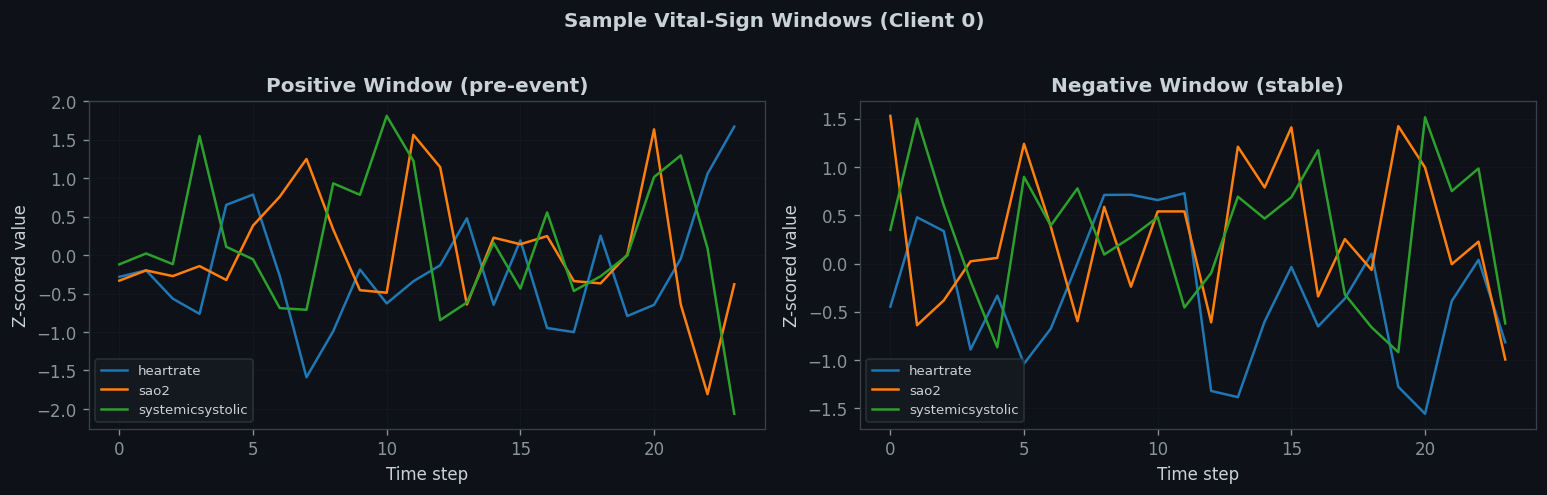

In [4]:
sample_cid = list(client_datasets.keys())[0]
X_sample, y_sample = client_datasets[sample_cid]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

pos_idx = np.where(y_sample == 1)[0]
neg_idx = np.where(y_sample == 0)[0]

if len(pos_idx) > 0:
    window = X_sample[pos_idx[0]]
    for i, feat in enumerate(["heartrate", "sao2", "systemicsystolic"]):
        fi = VITAL_FEATURES.index(feat)
        axes[0].plot(window[:, fi], label=feat, linewidth=1.5)
    axes[0].set_title("Positive Window (pre-event)", fontweight="bold")
    axes[0].legend(fontsize=8)
    axes[0].set_xlabel("Time step")
    axes[0].set_ylabel("Z-scored value")
    axes[0].grid(True, alpha=0.3)

if len(neg_idx) > 0:
    window = X_sample[neg_idx[0]]
    for i, feat in enumerate(["heartrate", "sao2", "systemicsystolic"]):
        fi = VITAL_FEATURES.index(feat)
        axes[1].plot(window[:, fi], label=feat, linewidth=1.5)
    axes[1].set_title("Negative Window (stable)", fontweight="bold")
    axes[1].legend(fontsize=8)
    axes[1].set_xlabel("Time step")
    axes[1].set_ylabel("Z-scored value")
    axes[1].grid(True, alpha=0.3)

plt.suptitle(f"Sample Vital-Sign Windows (Client {sample_cid})", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 4. LSTM Model Architecture

The core model is a **2-layer stacked LSTM** with dropout and a fully-connected classification head. It ingests `(batch, seq_len, 11)` vital-sign windows and outputs 2-class logits for binary event prediction.

In [5]:
model = create_model(
    input_size=n_features,
    hidden_size=128,
    num_layers=2,
    dropout=0.3,
)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 60)
print("LSTMAnomalyDetector (Opacus-compatible)")
print("=" * 60)
print(model)
print(f"\nTotal parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print(f"Model size (est.)    : {total_params * 4 / 1024:.1f} KB (float32)")

dummy = torch.randn(8, SEQ_LEN, n_features)
with torch.no_grad():
    logits = model(dummy)
print(f"\nForward pass: input {tuple(dummy.shape)} -> logits {tuple(logits.shape)}")
print(f"Sample output (softmax): {torch.softmax(logits[0], dim=0).numpy().round(4)}")

LSTMAnomalyDetector (Opacus-compatible)
LSTMAnomalyDetector(
  (lstm): DPLSTM(
    (dropout_layer): Dropout(p=0.3, inplace=False)
    (l0): DPLSTMCell(
      (ih): RNNLinear(in_features=11, out_features=512, bias=True)
      (hh): RNNLinear(in_features=128, out_features=512, bias=True)
    )
    (l1): DPLSTMCell(
      (ih): RNNLinear(in_features=128, out_features=512, bias=True)
      (hh): RNNLinear(in_features=128, out_features=512, bias=True)
    )
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)

Total parameters     : 204,546
Trainable parameters : 204,546
Model size (est.)    : 799.0 KB (float32)

Forward pass: input (8, 24, 11) -> logits (8, 2)
Sample output (softmax): [0.4868 0.5132]


---
## 5. Centralized Training Baseline

Before federated learning, we train a **centralized baseline** by pooling all clients' data into a single dataset. This gives an upper-bound performance reference.

In [6]:
X_all = np.concatenate([d[0] for d in client_datasets.values()])
y_all = np.concatenate([d[1] for d in client_datasets.values()])

rng_split = np.random.default_rng(42)
indices = np.arange(len(X_all))
rng_split.shuffle(indices)
split = int(0.8 * len(indices))

X_train_c, y_train_c = X_all[indices[:split]], y_all[indices[:split]]
X_val_c, y_val_c = X_all[indices[split:]], y_all[indices[split:]]

print(f"Centralized dataset: {len(X_train_c)} train / {len(X_val_c)} val")
print(f"Event rate: {y_all.mean()*100:.1f}%")

train_loader_c, val_loader_c = create_data_loaders(
    X_train_c, y_train_c, X_val_c, y_val_c, batch_size=64,
)

central_model = create_model(input_size=n_features)

CENTRAL_EPOCHS = 20
central_history = []

for epoch in range(1, CENTRAL_EPOCHS + 1):
    result = train_local(
        model=central_model,
        train_loader=train_loader_c,
        epochs=1,
        lr=0.001,
        device=device,
        class_weight_multiplier=1.0,
        use_dp=False,
    )
    central_model.load_state_dict(result.state_dict)

    val_result = evaluate(central_model, val_loader_c, device=device)
    central_history.append({
        "epoch": epoch,
        "train_loss": result.loss,
        "val_loss": val_result.loss,
        "val_acc": val_result.accuracy,
        "val_f1": val_result.f1,
        "val_auc": val_result.auc_roc,
        "val_prec": val_result.precision,
        "val_rec": val_result.recall,
    })

    if epoch % 5 == 0 or epoch == 1:
        print(
            f"  Epoch {epoch:>2d}/{CENTRAL_EPOCHS}: "
            f"loss={result.loss:.4f} | val_acc={val_result.accuracy:.3f} "
            f"f1={val_result.f1:.3f} auc={val_result.auc_roc:.3f}"
        )

print(f"\nFinal centralized: acc={central_history[-1]['val_acc']:.3f}, "
      f"f1={central_history[-1]['val_f1']:.3f}, auc={central_history[-1]['val_auc']:.3f}")

Centralized dataset: 1379 train / 345 val
Event rate: 28.3%
  Epoch  1/20: loss=0.3769 | val_acc=0.988 f1=0.977 auc=0.991
  Epoch  5/20: loss=0.0198 | val_acc=0.997 f1=0.994 auc=0.999
  Epoch 10/20: loss=0.0078 | val_acc=0.997 f1=0.994 auc=1.000
  Epoch 15/20: loss=0.0018 | val_acc=0.994 f1=0.989 auc=1.000
  Epoch 20/20: loss=0.0015 | val_acc=0.994 f1=0.989 auc=1.000

Final centralized: acc=0.994, f1=0.989, auc=1.000


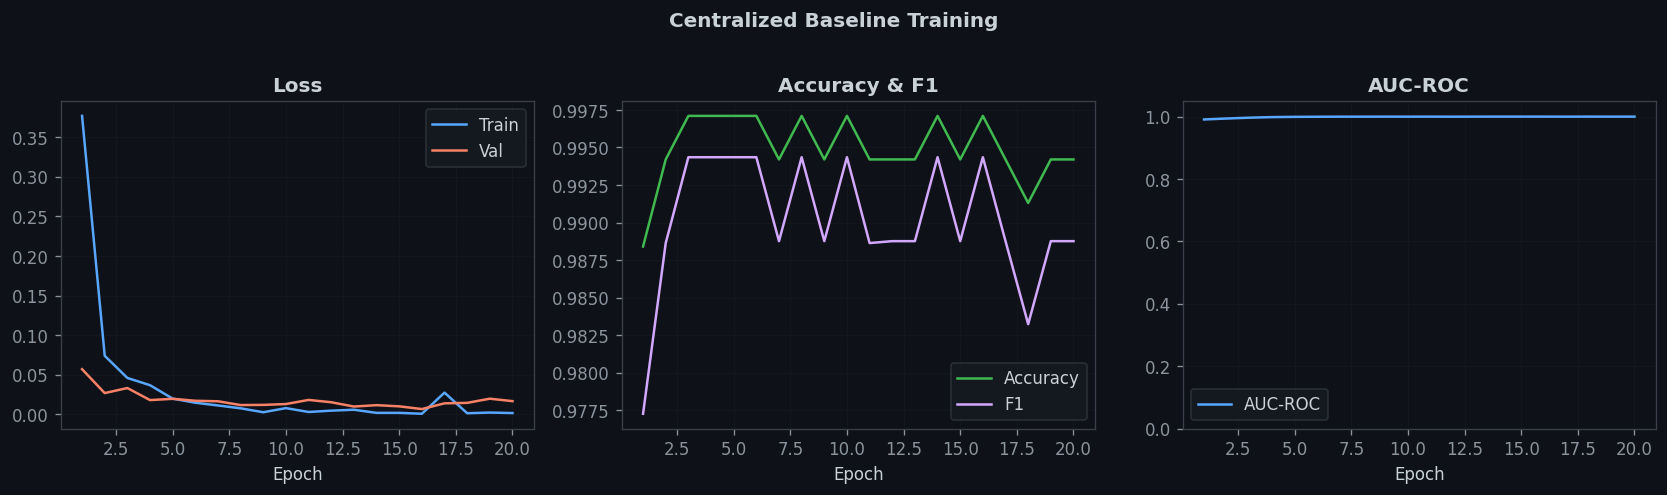

In [7]:
ch = pd.DataFrame(central_history)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(ch["epoch"], ch["train_loss"], color=ACCENT, label="Train", linewidth=1.5)
axes[0].plot(ch["epoch"], ch["val_loss"], color=ACCENT2, label="Val", linewidth=1.5)
axes[0].set_title("Loss", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(ch["epoch"], ch["val_acc"], color=ACCENT3, label="Accuracy", linewidth=1.5)
axes[1].plot(ch["epoch"], ch["val_f1"], color=ACCENT4, label="F1", linewidth=1.5)
axes[1].set_title("Accuracy & F1", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(ch["epoch"], ch["val_auc"], color=ACCENT, label="AUC-ROC", linewidth=1.5)
axes[2].set_title("AUC-ROC", fontweight="bold")
axes[2].set_xlabel("Epoch")
axes[2].set_ylim(0, 1.05)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle("Centralized Baseline Training", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 6. Federated Learning Simulation (FedProx)

Now we simulate the **full federated training loop**: the Orchestrator creates a job, each client trains locally via `LocalTrainer`, and the server aggregates using `FedProxAggregator` (FedAvg + proximal regularisation).

In [8]:
from agents.local_trainer import LocalTrainer
from app.core.orchestrator import Orchestrator

FL_ROUNDS = 10
LOCAL_EPOCHS = 3
LR = 0.001
BATCH_SIZE = 64
FEDPROX_MU = 0.01

trainers: dict[int, LocalTrainer] = {}
for cid, (X, y) in client_datasets.items():
    trainers[cid] = LocalTrainer(
        client_id=cid, client_X=X, client_y=y,
        input_size=n_features,
    )

orchestrator = Orchestrator()
config = {
    "num_rounds": FL_ROUNDS,
    "local_epochs": LOCAL_EPOCHS,
    "learning_rate": LR,
    "batch_size": BATCH_SIZE,
    "fedprox_mu": FEDPROX_MU,
    "dp_epsilon": 0,
    "n_features": n_features,
    "min_clients_per_round": 2,
    "class_weight_multiplier": 1.0,
    "threshold_beta": 1.0,
}

job = orchestrator.create_job(job_id=1, config=config)

for cid, trainer in trainers.items():
    orchestrator.connect_client(client_id=cid, num_samples=trainer.num_samples)

fl_history = []

for r in range(1, FL_ROUNDS + 1):
    orchestrator.start_round(job_id=1)
    global_state, _, _ = orchestrator.get_global_model(1)

    round_metrics_list = []
    for cid, trainer in trainers.items():
        local_state, metrics = trainer.train_round(
            global_state=global_state,
            epochs=LOCAL_EPOCHS, lr=LR, batch_size=BATCH_SIZE,
            fedprox_mu=FEDPROX_MU,
            use_dp=False, dp_epsilon=0,
        )
        orchestrator.receive_update(
            client_id=str(cid), job_id=1, round_number=r,
            update=local_state,
            metrics={"local_loss": metrics["local_loss"],
                     "local_accuracy": metrics["local_accuracy"],
                     "num_samples": metrics["num_samples"],
                     "dp_epsilon_spent": 0, "cumulative_epsilon": 0,
                     "training_time_ms": metrics["training_time_ms"],
                     "f1": metrics["f1"], "auc_roc": metrics["auc_roc"],
                     "precision": metrics["precision"], "recall": metrics["recall"],
                     "optimal_threshold": metrics["optimal_threshold"]},
        )
        round_metrics_list.append(metrics)

    avg = lambda k: np.mean([m[k] for m in round_metrics_list])
    fl_history.append({
        "round": r,
        "avg_loss": avg("local_loss"),
        "avg_acc": avg("local_accuracy"),
        "avg_f1": avg("f1"),
        "avg_auc": avg("auc_roc"),
        "avg_prec": avg("precision"),
        "avg_rec": avg("recall"),
    })

    print(
        f"  Round {r:>2d}/{FL_ROUNDS}: "
        f"loss={fl_history[-1]['avg_loss']:.4f} | "
        f"acc={fl_history[-1]['avg_acc']:.3f} "
        f"f1={fl_history[-1]['avg_f1']:.3f} "
        f"auc={fl_history[-1]['avg_auc']:.3f}"
    )

print(f"\nFederated final: acc={fl_history[-1]['avg_acc']:.3f}, "
      f"f1={fl_history[-1]['avg_f1']:.3f}, auc={fl_history[-1]['avg_auc']:.3f}")

  Round  1/10: loss=0.4531 | acc=0.989 f1=0.981 auc=0.993
  Round  2/10: loss=0.0660 | acc=0.986 f1=0.971 auc=0.995
  Round  3/10: loss=0.0431 | acc=0.994 f1=0.990 auc=0.998
  Round  4/10: loss=0.0364 | acc=0.994 f1=0.990 auc=0.999
  Round  5/10: loss=0.0370 | acc=0.994 f1=0.986 auc=0.999
  Round  6/10: loss=0.0341 | acc=0.994 f1=0.986 auc=0.999
  Round  7/10: loss=0.0324 | acc=0.994 f1=0.986 auc=1.000
  Round  8/10: loss=0.0262 | acc=0.994 f1=0.986 auc=1.000
  Round  9/10: loss=0.0211 | acc=0.997 f1=0.996 auc=1.000
  Round 10/10: loss=0.0200 | acc=0.997 f1=0.996 auc=1.000

Federated final: acc=0.997, f1=0.996, auc=1.000


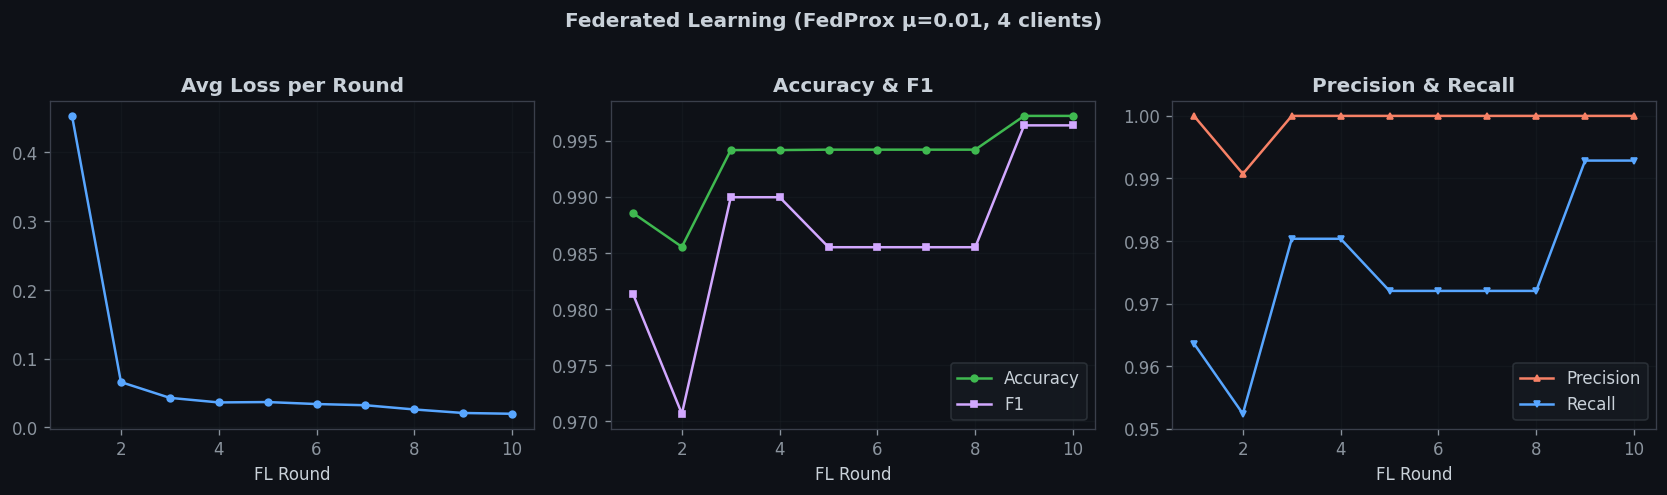

In [9]:
fh = pd.DataFrame(fl_history)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(fh["round"], fh["avg_loss"], color=ACCENT, marker="o", ms=4, linewidth=1.5)
axes[0].set_title("Avg Loss per Round", fontweight="bold")
axes[0].set_xlabel("FL Round")
axes[0].grid(True, alpha=0.3)

axes[1].plot(fh["round"], fh["avg_acc"], color=ACCENT3, marker="o", ms=4, label="Accuracy", linewidth=1.5)
axes[1].plot(fh["round"], fh["avg_f1"], color=ACCENT4, marker="s", ms=4, label="F1", linewidth=1.5)
axes[1].set_title("Accuracy & F1", fontweight="bold")
axes[1].set_xlabel("FL Round")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(fh["round"], fh["avg_prec"], color=ACCENT2, marker="^", ms=4, label="Precision", linewidth=1.5)
axes[2].plot(fh["round"], fh["avg_rec"], color=ACCENT, marker="v", ms=4, label="Recall", linewidth=1.5)
axes[2].set_title("Precision & Recall", fontweight="bold")
axes[2].set_xlabel("FL Round")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle(f"Federated Learning (FedProx μ={FEDPROX_MU}, {N_CLIENTS} clients)", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 7. Differential Privacy (Opacus DP-SGD)

AegisHealth supports **record-level differential privacy** via Opacus during local training. Per-sample gradient clipping and calibrated noise ensure that no individual patient's data can be reverse-engineered from model updates.

In [10]:
DP_EPSILON = 8.0
DP_DELTA = 1e-5
DP_MAX_GRAD_NORM = 1.0
DP_EPOCHS = 5

dp_model = create_model(input_size=n_features)

print("Training with Differential Privacy (Opacus)...")
print(f"  Target ε={DP_EPSILON}, δ={DP_DELTA}, max_grad_norm={DP_MAX_GRAD_NORM}\n")

dp_result = train_local(
    model=dp_model,
    train_loader=train_loader_c,
    epochs=DP_EPOCHS,
    lr=0.001,
    device=device,
    class_weight_multiplier=1.0,
    use_dp=True,
    dp_epsilon=DP_EPSILON,
    dp_delta=DP_DELTA,
    dp_max_grad_norm=DP_MAX_GRAD_NORM,
)

print(f"DP Training complete:")
print(f"  Loss          : {dp_result.loss:.4f}")
print(f"  Accuracy      : {dp_result.accuracy:.3f}")
print(f"  F1            : {dp_result.f1:.3f}")
print(f"  AUC-ROC       : {dp_result.auc_roc:.3f}")
print(f"  ε spent       : {dp_result.dp_epsilon_spent:.2f}")
print(f"  Training time : {dp_result.training_time_ms:.0f} ms")

Training with Differential Privacy (Opacus)...
  Target ε=8.0, δ=1e-05, max_grad_norm=1.0

DP Training complete:
  Loss          : 0.5823
  Accuracy      : 0.982
  F1            : 0.964
  AUC-ROC       : 0.998
  ε spent       : 8.00
  Training time : 14021 ms



--- Privacy Accountant Demo ---

Budget: ε=50.0
After 10 rounds:
  Total ε spent    : 79.96
  Budget remaining : 0.00
  Exhausted?       : True


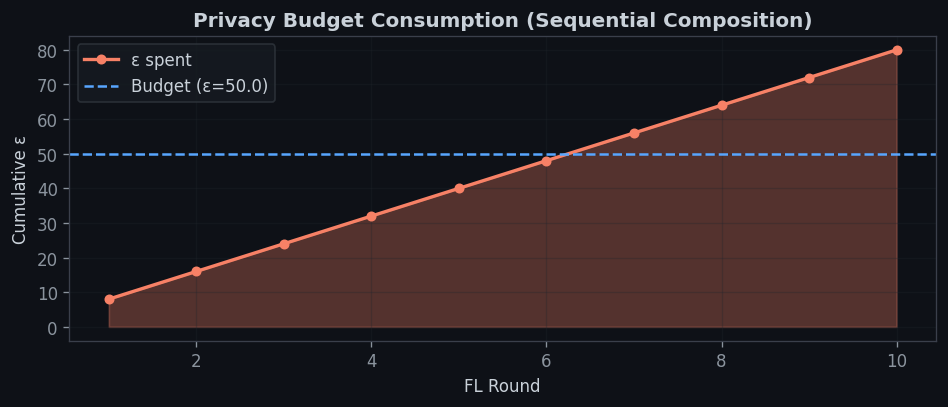

In [11]:
print("\n--- Privacy Accountant Demo ---\n")

accountant = PrivacyAccountant(epsilon_budget=50.0, delta=1e-5)
budget_trace = []

for r in range(1, 11):
    accountant.record_round(dp_result.dp_epsilon_spent)
    budget_trace.append({
        "round": r,
        "spent": accountant.total_epsilon_spent,
        "remaining": accountant.budget_remaining,
    })

print(f"Budget: ε={accountant.epsilon_budget}")
print(f"After {accountant.num_rounds} rounds:")
print(f"  Total ε spent    : {accountant.total_epsilon_spent:.2f}")
print(f"  Budget remaining : {accountant.budget_remaining:.2f}")
print(f"  Exhausted?       : {accountant.budget_exhausted}")

bt = pd.DataFrame(budget_trace)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.fill_between(bt["round"], 0, bt["spent"], alpha=0.3, color=ACCENT2)
ax.plot(bt["round"], bt["spent"], color=ACCENT2, marker="o", ms=5, linewidth=2, label="ε spent")
ax.axhline(y=accountant.epsilon_budget, color=ACCENT, linestyle="--", linewidth=1.5, label=f"Budget (ε={accountant.epsilon_budget})")
ax.set_xlabel("FL Round")
ax.set_ylabel("Cumulative ε")
ax.set_title("Privacy Budget Consumption (Sequential Composition)", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 8. Homomorphic Encryption (TenSEAL CKKS)

AegisHealth supports **secure aggregation** via CKKS homomorphic encryption. The server aggregates encrypted model updates without ever seeing plaintext weights — addition and scalar multiplication on ciphertexts is all FedAvg requires.

In [12]:
import time

tiny_model = LSTMAnomalyDetector(input_size=n_features, hidden_size=16, num_layers=1, dropout=0.0)
tiny_state = tiny_model.state_dict()
param_count = sum(p.numel() for p in tiny_model.parameters())
plaintext_bytes = sum(v.nelement() * v.element_size() for v in tiny_state.values())

print(f"Demo model: {param_count:,} params ({plaintext_bytes:,} bytes plaintext)\n")

print("Step 1: Create HE context (server-side, with secret key)")
ctx = create_he_context(poly_modulus_degree=8192)
print(f"  CKKS context created (poly_mod_degree=8192)\n")

print("Step 2: Create public context (sent to clients)")
pub_ctx = create_public_context(ctx)
print(f"  Public context ready (no secret key)\n")

state_a = {k: v + torch.randn_like(v) * 0.01 for k, v in tiny_state.items()}
state_b = {k: v + torch.randn_like(v) * 0.01 for k, v in tiny_state.items()}

print("Step 3: Clients encrypt their model updates")
t0 = time.time()
enc_a, meta_a = encrypt_state_dict(state_a, pub_ctx)
enc_b, meta_b = encrypt_state_dict(state_b, pub_ctx)
enc_time = (time.time() - t0) * 1000

ct_bytes = ciphertext_size_bytes(enc_a)
print(f"  Encryption time  : {enc_time:.0f} ms (2 clients)")
print(f"  Ciphertext size  : {ct_bytes:,} bytes per client")
print(f"  Overhead ratio   : {ct_bytes / plaintext_bytes:.1f}x\n")

print("Step 4: Server aggregates on encrypted data")
t1 = time.time()
agg_enc = encrypted_weighted_average([enc_a, enc_b], weights=[100.0, 150.0])
agg_time = (time.time() - t1) * 1000
print(f"  Aggregation time : {agg_time:.0f} ms\n")

print("Step 5: Server decrypts aggregated result")
import tenseal as ts
agg_linked = []
for vec in agg_enc:
    linked = ts.lazy_ckks_vector_from(vec.serialize())
    linked.link_context(ctx)
    agg_linked.append(linked)

t2 = time.time()
keys = list(tiny_state.keys())
decrypted = decrypt_state_dict(agg_linked, keys, meta_a)
dec_time = (time.time() - t2) * 1000
print(f"  Decryption time  : {dec_time:.0f} ms\n")

print("Step 6: Verify correctness vs plaintext FedAvg")
plaintext_avg = federated_average(tiny_state, [state_a, state_b], [100.0, 150.0])

max_err = max(
    (decrypted[k] - plaintext_avg[k]).abs().max().item() for k in keys
)
print(f"  Max absolute error (HE vs plaintext): {max_err:.2e}")
print(f"  Status: {'PASS — within CKKS precision' if max_err < 0.01 else 'WARN — check parameters'}")

Demo model: 1,890 params (7,560 bytes plaintext)

Step 1: Create HE context (server-side, with secret key)
  CKKS context created (poly_mod_degree=8192)

Step 2: Create public context (sent to clients)
  Public context ready (no secret key)

Step 3: Clients encrypt their model updates
  Encryption time  : 24 ms (2 clients)
  Ciphertext size  : 2,006,333 bytes per client
  Overhead ratio   : 265.4x

Step 4: Server aggregates on encrypted data
  Aggregation time : 4 ms

Step 5: Server decrypts aggregated result
  Decryption time  : 3 ms

Step 6: Verify correctness vs plaintext FedAvg
  Max absolute error (HE vs plaintext): 4.47e-08
  Status: PASS — within CKKS precision


In [13]:
print("\n--- End-to-end secure_aggregate() ---\n")

client_states = [state_a, state_b]
client_weights = [100.0, 150.0]
he_ctx = create_he_context()

agg_result, stats = secure_aggregate(client_states, client_weights, he_ctx)

print("HE Aggregation Statistics:")
for k, v in stats.items():
    if "time" in k:
        print(f"  {k:<30s}: {v:>10.1f} ms")
    elif "bytes" in k:
        print(f"  {k:<30s}: {v:>10,} bytes")
    else:
        print(f"  {k:<30s}: {v:>10.1f}x")


--- End-to-end secure_aggregate() ---

HE Aggregation Statistics:
  encrypt_time_ms               :       24.4 ms
  aggregate_time_ms             :        4.0 ms
  decrypt_time_ms               :        2.5 ms
  ciphertext_bytes_per_client   :  2,005,628 bytes
  plaintext_bytes               :      7,560 bytes
  overhead_ratio                :      265.3x


---
## 9. Threshold Optimisation (F-beta)

In clinical settings, **recall (sensitivity)** often matters more than precision. The `find_optimal_threshold` function sweeps probability thresholds to maximise the F-beta score, where β > 1 emphasises recall.

  β=0.5: optimal threshold=0.766, F-beta=0.998
  β=1.0: optimal threshold=0.766, F-beta=0.994
  β=2.0: optimal threshold=0.766, F-beta=0.991


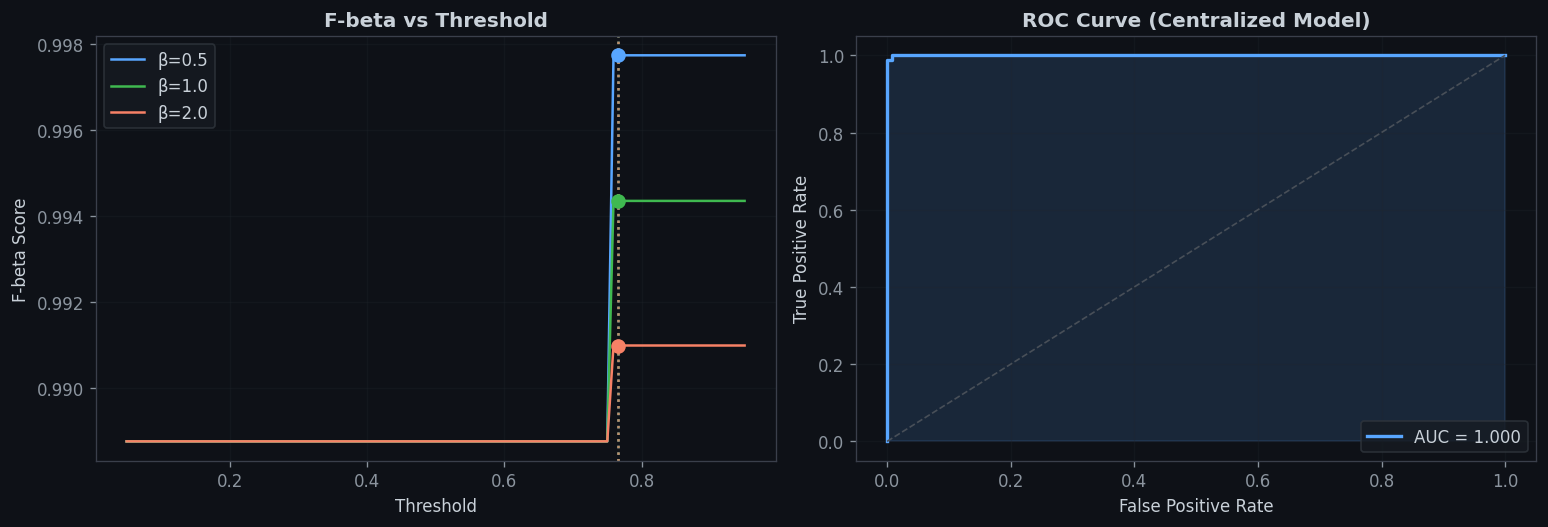

In [14]:
from sklearn.metrics import fbeta_score

central_model.load_state_dict(result.state_dict)
labels, probs = collect_probs(central_model, val_loader_c, device=device)

betas = [0.5, 1.0, 2.0]
thresholds = np.linspace(0.05, 0.95, 100)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

colors = [ACCENT, ACCENT3, ACCENT2]
for beta, color in zip(betas, colors):
    scores = [fbeta_score(labels, (probs >= t).astype(int), beta=beta, zero_division=0)
              for t in thresholds]
    opt_t, opt_s = find_optimal_threshold(labels, probs, beta=beta)
    axes[0].plot(thresholds, scores, color=color, linewidth=1.5, label=f"β={beta}")
    axes[0].axvline(x=opt_t, color=color, linestyle=":", alpha=0.7)
    axes[0].scatter([opt_t], [opt_s], color=color, zorder=5, s=60)
    print(f"  β={beta}: optimal threshold={opt_t:.3f}, F-beta={opt_s:.3f}")

axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("F-beta Score")
axes[0].set_title("F-beta vs Threshold", fontweight="bold")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

if len(np.unique(labels)) >= 2:
    fpr, tpr, _ = roc_curve(labels, probs)
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color=ACCENT, linewidth=2, label=f"AUC = {roc_auc:.3f}")
    axes[1].plot([0, 1], [0, 1], color="#484f58", linestyle="--", linewidth=1)
    axes[1].fill_between(fpr, tpr, alpha=0.15, color=ACCENT)
else:
    axes[1].text(0.5, 0.5, "Only one class in val set", ha="center", va="center",
                 fontsize=12, color="#8b949e", transform=axes[1].transAxes)

axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve (Centralized Model)", fontweight="bold")
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 10. ONNX Export

Trained models are exported to **ONNX** for deployment. The export includes dynamic batch axes so the model can serve single-patient or batch predictions.

In [15]:
import tempfile, os

export_model = create_model(input_size=n_features)
export_model.load_state_dict(result.state_dict)
export_model.eval()

tmpdir = tempfile.mkdtemp(prefix="aegis_onnx_")
pt_path = os.path.join(tmpdir, "model.pt")
onnx_path = os.path.join(tmpdir, "model.onnx")

torch.save(result.state_dict, pt_path)
print(f"PyTorch state_dict saved: {os.path.getsize(pt_path):,} bytes")

dummy_input = torch.zeros(1, SEQ_LEN, n_features, dtype=torch.float32)
torch.onnx.export(
    export_model,
    dummy_input,
    onnx_path,
    input_names=["input"],
    output_names=["logits"],
    dynamic_axes={"input": {0: "batch_size"}, "logits": {0: "batch_size"}},
    opset_version=18,
)

print(f"ONNX model exported : {os.path.getsize(onnx_path):,} bytes")
print(f"Input shape         : (batch, {SEQ_LEN}, {n_features})")
print(f"Output shape        : (batch, 2)")
print(f"Saved to            : {tmpdir}")

PyTorch state_dict saved: 1,640,317 bytes
[torch.onnx] Obtain model graph for `LSTMAnomalyDetector([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `LSTMAnomalyDetector([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
Applied 3 of general pattern rewrite rules.
[torch.onnx] Optimize the ONNX graph... ✅
ONNX model exported : 862,378 bytes
Input shape         : (batch, 24, 11)
Output shape        : (batch, 2)
Saved to            : /var/folders/s7/1wzt0ftx4l3b0jz80z3708d00000gn/T/aegis_onnx_8tqw5lmk


In [16]:
try:
    import onnxruntime as ort

    session = ort.InferenceSession(onnx_path)
    test_input = X_val_c[:4].astype(np.float32)
    onnx_out = session.run(None, {"input": test_input})[0]

    export_model.eval()
    with torch.no_grad():
        pt_out = export_model(torch.from_numpy(test_input)).numpy()

    diff = np.abs(onnx_out - pt_out).max()
    print(f"ONNX vs PyTorch max diff: {diff:.2e}")
    print(f"ONNX output (4 samples):\n{onnx_out.round(4)}")
    print("\nONNX Runtime verification: PASS" if diff < 1e-4 else "\nONNX Runtime verification: WARN")
except ImportError:
    print("onnxruntime not installed — skipping ONNX inference verification.")
    print("Install with: pip install onnxruntime")

onnxruntime not installed — skipping ONNX inference verification.
Install with: pip install onnxruntime


---
## 11. Comprehensive Evaluation & Comparison

Compare the **centralized baseline** vs **federated model**, examine per-client performance, and generate a confusion matrix.

In [17]:
federated_model = create_model(input_size=n_features)
final_global_state, _, _ = orchestrator.get_global_model(1)
federated_model.load_state_dict(final_global_state)

central_eval = evaluate(central_model, val_loader_c, device=device)
fed_eval = evaluate(federated_model, val_loader_c, device=device)

comparison = pd.DataFrame([
    {
        "Model": "Centralized",
        "Accuracy": central_eval.accuracy,
        "F1": central_eval.f1,
        "AUC-ROC": central_eval.auc_roc,
        "Precision": central_eval.precision,
        "Recall": central_eval.recall,
        "Loss": central_eval.loss,
    },
    {
        "Model": f"Federated (FedProx μ={FEDPROX_MU})",
        "Accuracy": fed_eval.accuracy,
        "F1": fed_eval.f1,
        "AUC-ROC": fed_eval.auc_roc,
        "Precision": fed_eval.precision,
        "Recall": fed_eval.recall,
        "Loss": fed_eval.loss,
    },
]).set_index("Model")

print("\n" + "=" * 70)
print("MODEL COMPARISON (evaluated on pooled validation set)")
print("=" * 70)
print(comparison.round(4).to_string())
print()


MODEL COMPARISON (evaluated on pooled validation set)
                            Accuracy      F1  AUC-ROC  Precision  Recall    Loss
Model                                                                           
Centralized                   0.9942  0.9888   0.9999     0.9888  0.9888  0.0166
Federated (FedProx μ=0.01)    0.9971  0.9944   0.9994     1.0000  0.9888  0.0176



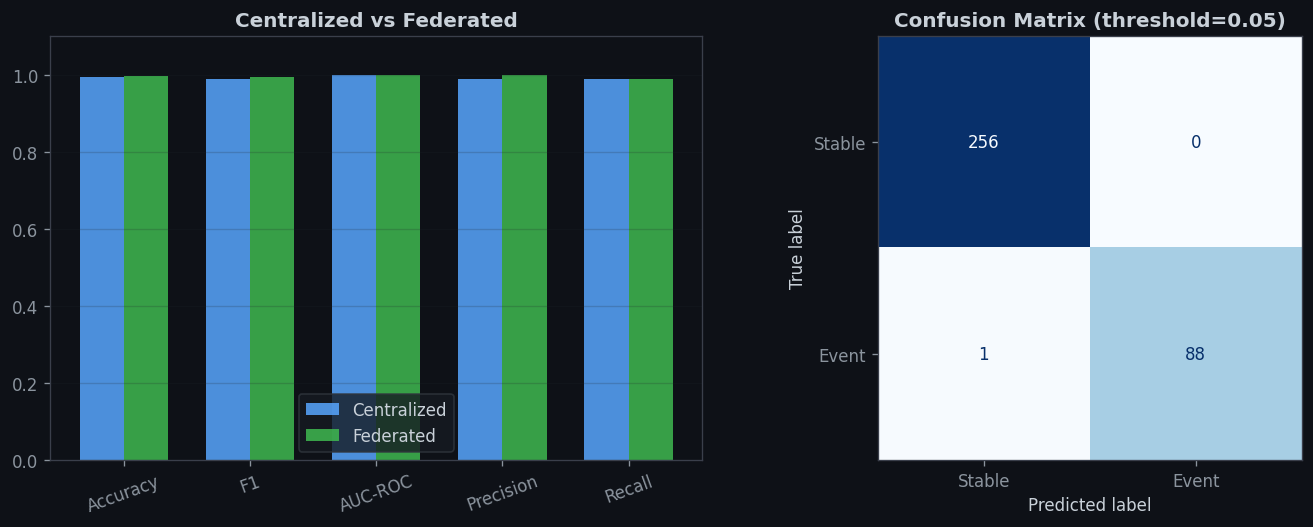

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

metrics_to_plot = ["Accuracy", "F1", "AUC-ROC", "Precision", "Recall"]
x = np.arange(len(metrics_to_plot))
width = 0.35

central_vals = [comparison.loc["Centralized", m] for m in metrics_to_plot]
fed_vals = [comparison.iloc[1][m] for m in metrics_to_plot]

axes[0].bar(x - width/2, central_vals, width, label="Centralized", color=ACCENT, alpha=0.85)
axes[0].bar(x + width/2, fed_vals, width, label="Federated", color=ACCENT3, alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_to_plot, rotation=20)
axes[0].set_ylim(0, 1.1)
axes[0].set_title("Centralized vs Federated", fontweight="bold")
axes[0].legend()
axes[0].grid(True, alpha=0.2, axis="y")

fed_labels, fed_probs = collect_probs(federated_model, val_loader_c, device=device)
opt_t, _ = find_optimal_threshold(fed_labels, fed_probs, beta=1.0)
fed_preds = (fed_probs >= opt_t).astype(int)

if len(np.unique(fed_labels)) >= 2:
    cm = confusion_matrix(fed_labels, fed_preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Stable", "Event"])
    disp.plot(ax=axes[1], cmap="Blues", colorbar=False)
    axes[1].set_title(f"Confusion Matrix (threshold={opt_t:.2f})", fontweight="bold")
else:
    axes[1].text(0.5, 0.5, "Single class in val set", ha="center", va="center",
                 fontsize=12, color="#8b949e", transform=axes[1].transAxes)
    axes[1].set_title("Confusion Matrix", fontweight="bold")

plt.tight_layout()
plt.show()

In [19]:
print("\n--- Per-Client Evaluation (Federated Global Model) ---\n")

per_client_metrics = []

for cid, (X, y) in client_datasets.items():
    rng_c = np.random.default_rng(42)
    idx = np.arange(len(X))
    rng_c.shuffle(idx)
    split_c = int(0.8 * len(idx))
    _, val_loader = create_data_loaders(
        X[idx[:split_c]], y[idx[:split_c]],
        X[idx[split_c:]], y[idx[split_c:]],
        batch_size=64,
    )
    ev = evaluate(federated_model, val_loader, device=device)
    per_client_metrics.append({
        "Client": cid,
        "Samples": len(X),
        "Event Rate": f"{y.mean()*100:.1f}%",
        "Accuracy": ev.accuracy,
        "F1": ev.f1,
        "AUC-ROC": ev.auc_roc,
    })

pcm = pd.DataFrame(per_client_metrics).set_index("Client")
print(pcm.round(4).to_string())


--- Per-Client Evaluation (Federated Global Model) ---

        Samples Event Rate  Accuracy   F1  AUC-ROC
Client                                            
0           453      38.2%       1.0  1.0      1.0
1           416      14.2%       1.0  1.0      1.0
2           441      35.6%       1.0  1.0      1.0
3           414      23.9%       1.0  1.0      1.0


---
## 12. Federated Learning with DP — Combined Demo

Run a full FL simulation **with differential privacy enabled** to demonstrate the privacy-utility trade-off in federated training.

In [20]:
FL_DP_ROUNDS = 5
FL_DP_EPSILON = 8.0

dp_trainers: dict[int, LocalTrainer] = {}
for cid, (X, y) in client_datasets.items():
    dp_trainers[cid] = LocalTrainer(
        client_id=cid, client_X=X, client_y=y,
        input_size=n_features,
    )

dp_orchestrator = Orchestrator()
dp_config = {
    "num_rounds": FL_DP_ROUNDS,
    "local_epochs": 3,
    "learning_rate": LR,
    "batch_size": BATCH_SIZE,
    "fedprox_mu": FEDPROX_MU,
    "dp_epsilon": FL_DP_EPSILON,
    "dp_delta": 1e-5,
    "dp_max_grad_norm": 1.0,
    "n_features": n_features,
    "min_clients_per_round": 2,
    "class_weight_multiplier": 1.0,
    "threshold_beta": 1.0,
}

dp_job = dp_orchestrator.create_job(job_id=2, config=dp_config)
for cid, trainer in dp_trainers.items():
    dp_orchestrator.connect_client(client_id=cid, num_samples=trainer.num_samples)

dp_accountant = PrivacyAccountant(epsilon_budget=FL_DP_EPSILON * FL_DP_ROUNDS, delta=1e-5)
fl_dp_history = []

print(f"FL + DP Training ({FL_DP_ROUNDS} rounds, ε={FL_DP_EPSILON}/round)\n")

for r in range(1, FL_DP_ROUNDS + 1):
    dp_orchestrator.start_round(job_id=2)
    global_state, _, _ = dp_orchestrator.get_global_model(2)

    round_eps = []
    round_metrics_list = []

    for cid, trainer in dp_trainers.items():
        local_state, metrics = trainer.train_round(
            global_state=global_state,
            epochs=3, lr=LR, batch_size=BATCH_SIZE,
            fedprox_mu=FEDPROX_MU,
            use_dp=True, dp_epsilon=FL_DP_EPSILON,
            dp_delta=1e-5, dp_max_grad_norm=1.0,
        )
        dp_orchestrator.receive_update(
            client_id=str(cid), job_id=2, round_number=r,
            update=local_state,
            metrics={"local_loss": metrics["local_loss"],
                     "local_accuracy": metrics["local_accuracy"],
                     "num_samples": metrics["num_samples"],
                     "dp_epsilon_spent": metrics["dp_epsilon_spent"],
                     "cumulative_epsilon": metrics["cumulative_epsilon"],
                     "training_time_ms": metrics["training_time_ms"],
                     "f1": metrics["f1"], "auc_roc": metrics["auc_roc"],
                     "precision": metrics["precision"], "recall": metrics["recall"],
                     "optimal_threshold": metrics.get("optimal_threshold", 0.5)},
        )
        round_metrics_list.append(metrics)
        round_eps.append(metrics["dp_epsilon_spent"])

    dp_accountant.record_round(np.mean(round_eps))

    avg_m = lambda k: np.mean([m[k] for m in round_metrics_list])
    fl_dp_history.append({
        "round": r,
        "avg_loss": avg_m("local_loss"),
        "avg_acc": avg_m("local_accuracy"),
        "avg_f1": avg_m("f1"),
        "avg_auc": avg_m("auc_roc"),
        "cumulative_eps": dp_accountant.total_epsilon_spent,
    })

    print(
        f"  Round {r}/{FL_DP_ROUNDS}: "
        f"loss={fl_dp_history[-1]['avg_loss']:.4f} "
        f"acc={fl_dp_history[-1]['avg_acc']:.3f} "
        f"f1={fl_dp_history[-1]['avg_f1']:.3f} "
        f"ε_total={dp_accountant.total_epsilon_spent:.2f}"
    )

print(f"\nPrivacy summary: {dp_accountant.summary()}")

FL + DP Training (5 rounds, ε=8.0/round)

  Round 1/5: loss=0.6972 acc=0.874 f1=0.780 ε_total=7.99
  Round 2/5: loss=0.6787 acc=0.986 f1=0.970 ε_total=15.99
  Round 3/5: loss=0.6555 acc=0.991 f1=0.986 ε_total=23.98
  Round 4/5: loss=0.6201 acc=0.994 f1=0.993 ε_total=31.97
  Round 5/5: loss=0.5664 acc=0.997 f1=0.996 ε_total=39.96

Privacy summary: {'epsilon_budget': 40.0, 'delta': 1e-05, 'total_epsilon_spent': np.float64(39.963984031524646), 'budget_remaining': np.float64(0.03601596847535404), 'num_rounds': 5, 'budget_exhausted': np.False_}


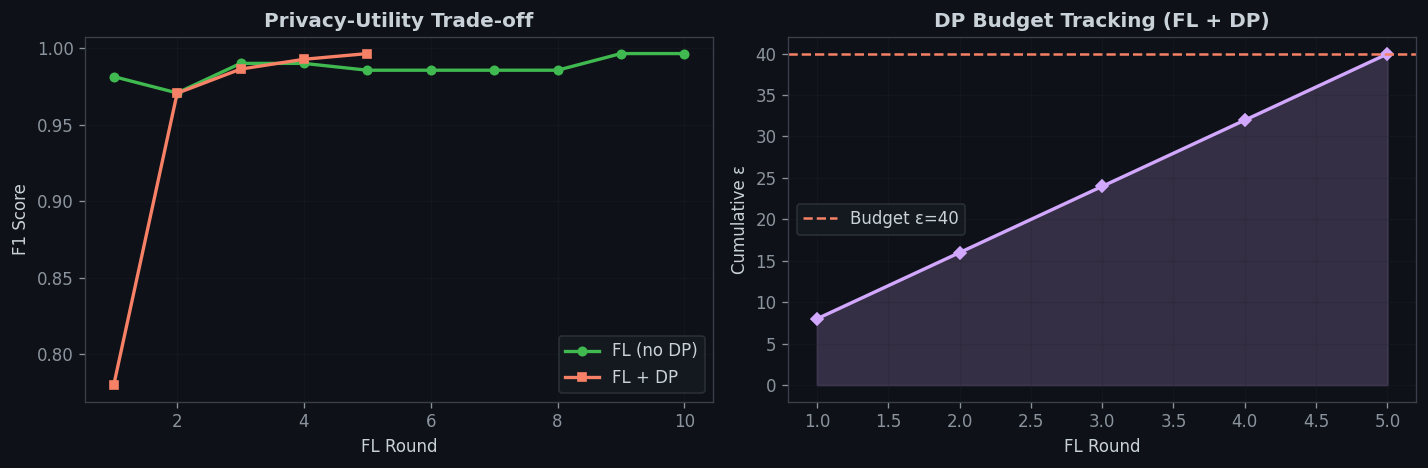

In [21]:
fdh = pd.DataFrame(fl_dp_history)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(fh["round"], fh["avg_f1"], color=ACCENT3, marker="o", ms=5, linewidth=2, label="FL (no DP)")
ax1.plot(fdh["round"], fdh["avg_f1"], color=ACCENT2, marker="s", ms=5, linewidth=2, label="FL + DP")
ax1.set_xlabel("FL Round")
ax1.set_ylabel("F1 Score")
ax1.set_title("Privacy-Utility Trade-off", fontweight="bold")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(fdh["round"], fdh["cumulative_eps"], color=ACCENT4, marker="D", ms=5, linewidth=2)
ax2.axhline(y=dp_accountant.epsilon_budget, color=ACCENT2, linestyle="--", label=f"Budget ε={dp_accountant.epsilon_budget:.0f}")
ax2.fill_between(fdh["round"], 0, fdh["cumulative_eps"], alpha=0.2, color=ACCENT4)
ax2.set_xlabel("FL Round")
ax2.set_ylabel("Cumulative ε")
ax2.set_title("DP Budget Tracking (FL + DP)", fontweight="bold")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Summary

This notebook demonstrated the complete AegisHealth ML pipeline:

| Component | Module | Status |
|-----------|--------|--------|
| Data preprocessing | `app.data.preprocessor` | Sliding windows, z-score, labelling |
| Client partitioning | `app.data.partitioner` | Multi-hospital client discovery |
| LSTM model | `app.ml.lstm_model` | 2-layer stacked LSTM, Opacus-compatible |
| Centralized training | `app.ml.trainer` | Class-weighted CrossEntropy, Adam |
| Federated Learning | `app.core.orchestrator` + `agents.local_trainer` | FedProx with server-side aggregation |
| FedAvg aggregation | `app.core.aggregator` | Weighted averaging of client models |
| Differential Privacy | `app.ml.dp_engine` (Opacus) | Per-sample clipping + noise |
| Privacy Accounting | `app.ml.dp_engine.PrivacyAccountant` | Sequential composition tracking |
| Homomorphic Encryption | `app.ml.he_engine` (TenSEAL) | CKKS secure aggregation |
| Threshold optimisation | `app.ml.trainer.find_optimal_threshold` | F-beta sweep for clinical sensitivity |
| Model export | ONNX via `torch.onnx.export` | Dynamic-batch production export |

In [22]:
shutil.rmtree(SYNTH_DIR, ignore_errors=True)
shutil.rmtree(tmpdir, ignore_errors=True)
print("Temporary directories cleaned up.")

Temporary directories cleaned up.
